In [206]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder
import re
from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    Ridge,
    LassoCV,
    RidgeCV,
    LogisticRegression,
)
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
)

In [207]:
df=pd.read_csv("phones.csv")
df.head()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (USA),Launched Year
0,Apple,iPhone 16 128GB,NaN,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,USD 799,2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,USD 849,2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,USD 899,2024
3,NaN,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,USD 899,2024
4,NaN,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,USD 949,2024


In [208]:
len(df)

930

<Axes: >

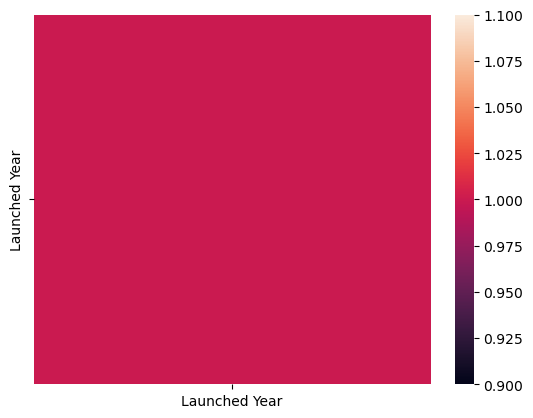

In [209]:
sns.heatmap(df.corr(numeric_only=True))

In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Company Name          854 non-null    object
 1   Model Name            930 non-null    object
 2   Mobile Weight         733 non-null    object
 3   RAM                   930 non-null    object
 4   Front Camera          930 non-null    object
 5   Back Camera           930 non-null    object
 6   Processor             930 non-null    object
 7   Battery Capacity      930 non-null    object
 8   Screen Size           930 non-null    object
 9   Launched Price (USA)  921 non-null    object
 10  Launched Year         930 non-null    int64 
dtypes: int64(1), object(10)
memory usage: 80.1+ KB


<Axes: xlabel='Company Name'>

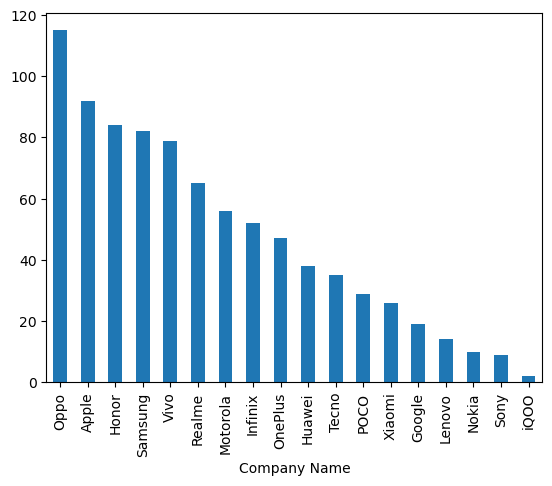

In [211]:
df['Company Name'].value_counts().plot.bar()

<Axes: >

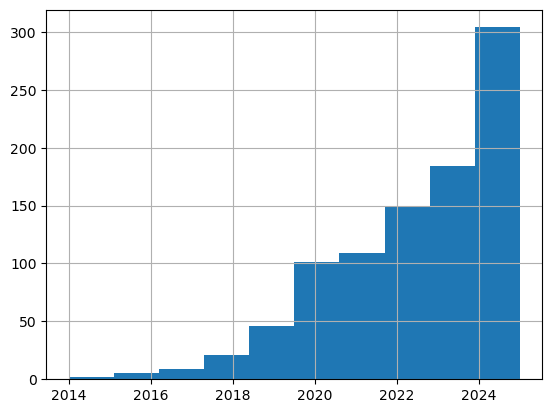

In [212]:
df['Launched Year'].hist()

In [213]:
df.isnull().sum()

Company Name             76
Model Name                0
Mobile Weight           197
RAM                       0
Front Camera              0
Back Camera               0
Processor                 0
Battery Capacity          0
Screen Size               0
Launched Price (USA)      9
Launched Year             0
dtype: int64

In [214]:
df.dropna(subset=['Launched Price (USA)'],inplace=True)

In [215]:
df.isna().sum()

Company Name             76
Model Name                0
Mobile Weight           196
RAM                       0
Front Camera              0
Back Camera               0
Processor                 0
Battery Capacity          0
Screen Size               0
Launched Price (USA)      0
Launched Year             0
dtype: int64

In [216]:
len(df['Model Name'].unique())

899

In [217]:
df.drop(columns=['Model Name'],inplace=True)

In [218]:
def preprocess_weight(value):
    if not pd.isna(value):
        num=re.findall(r"\d{3}",value)
        return float(num[0])

In [219]:
len(df['Mobile Weight'].unique())

135

In [220]:
df['Mobile Weight']=df['Mobile Weight'].apply(preprocess_weight)

In [221]:
df.head()

,Company Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (USA),Launched Year
0,Apple,NaN,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,USD 799,2024
1,Apple,174.0,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,USD 849,2024
2,Apple,174.0,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,USD 899,2024
3,NaN,203.0,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,USD 899,2024
4,NaN,203.0,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,USD 949,2024


In [222]:
df['RAM'].value_counts()

RAM
8GB           305
6GB           204
12GB          191
4GB           145
3GB            34
16GB           30
2GB             6
1.5GB           2
8GB / 12GB      2
10GB            1
1GB             1
Name: count, dtype: int64

In [223]:
def preprocess_ram(value):
    return float(value.split('GB')[0])

In [224]:
df['RAM']=df['RAM'].apply(preprocess_ram)

In [225]:
df['Front Camera'].value_counts()

Front Camera
16MP                                  209
32MP                                  205
8MP                                   165
12MP                                   81
5MP                                    47
13MP                                   43
12MP / 4K                              35
50MP                                   30
7MP                                    24
10MP                                   21
2MP                                    12
20MP                                   11
10.8MP                                  6
60MP                                    5
10.5MP                                  3
44MP                                    3
10MP, 4MP (UDC)                         3
60MP + 8MP                              3
25MP                                    2
60MP (ultrawide) + 8MP (telephoto)      2
20MP+8MP                                2
10.7MP                                  2
12MP + 12MP                             1
24MP                 

In [226]:
def preprocess_camera(value):
    val=re.findall(r"\d+",value)[0]
    return float(val)

    

In [227]:
df['Front Camera']=df['Front Camera'].apply(preprocess_camera)

In [228]:
df['Front Camera'].value_counts()

Front Camera
16.0    209
32.0    206
8.0     165
12.0    117
5.0      47
13.0     43
10.0     35
50.0     30
7.0      24
20.0     13
2.0      12
60.0     11
44.0      3
25.0      2
24.0      1
11.0      1
48.0      1
42.0      1
Name: count, dtype: int64

In [229]:
df['Back Camera']=df['Back Camera'].apply(preprocess_camera)

In [230]:
df.head()

,Company Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (USA),Launched Year
0,Apple,NaN,6.0,12.0,48.0,A17 Bionic,"3,600mAh",6.1 inches,USD 799,2024
1,Apple,174.0,6.0,12.0,48.0,A17 Bionic,"3,600mAh",6.1 inches,USD 849,2024
2,Apple,174.0,6.0,12.0,48.0,A17 Bionic,"3,600mAh",6.1 inches,USD 899,2024
3,NaN,203.0,6.0,12.0,48.0,A17 Bionic,"4,200mAh",6.7 inches,USD 899,2024
4,NaN,203.0,6.0,12.0,48.0,A17 Bionic,"4,200mAh",6.7 inches,USD 949,2024


In [231]:
len(df['Processor'].unique())

216

In [232]:
df.isnull().sum()

Company Name             76
Mobile Weight           196
RAM                       0
Front Camera              0
Back Camera               0
Processor                 0
Battery Capacity          0
Screen Size               0
Launched Price (USA)      0
Launched Year             0
dtype: int64

In [233]:
df.drop(columns=['Processor'],inplace=True)

In [234]:
df.head()

,Company Name,Mobile Weight,RAM,Front Camera,Back Camera,Battery Capacity,Screen Size,Launched Price (USA),Launched Year
0,Apple,NaN,6.0,12.0,48.0,"3,600mAh",6.1 inches,USD 799,2024
1,Apple,174.0,6.0,12.0,48.0,"3,600mAh",6.1 inches,USD 849,2024
2,Apple,174.0,6.0,12.0,48.0,"3,600mAh",6.1 inches,USD 899,2024
3,NaN,203.0,6.0,12.0,48.0,"4,200mAh",6.7 inches,USD 899,2024
4,NaN,203.0,6.0,12.0,48.0,"4,200mAh",6.7 inches,USD 949,2024


In [235]:
df['Battery Capacity'].value_counts()

Battery Capacity
5,000mAh    197
5000mAh      96
4,500mAh     46
4500mAh      38
5,200mAh     35
           ... 
7,500mAh      1
8,300mAh      1
8,850mAh      1
5065mAh       1
5110mAh       1
Name: count, Length: 147, dtype: int64

In [236]:
def preprocess_batery(value):
    val=value.split("mAh")[0]
    x=val.split(',')
    if len(x)==2:
        val1=float(x[0])
        val2=float(x[1])
        return val1*1000+val2
    else:
        return float(x[0])

In [237]:
df['Battery Capacity'].value_counts()

Battery Capacity
5,000mAh    197
5000mAh      96
4,500mAh     46
4500mAh      38
5,200mAh     35
           ... 
7,500mAh      1
8,300mAh      1
8,850mAh      1
5065mAh       1
5110mAh       1
Name: count, Length: 147, dtype: int64

In [238]:
df_c=df.copy()
df_c['Battery Capacity']=df_c['Battery Capacity'].apply(preprocess_batery)

In [239]:
df_c['Battery Capacity'].value_counts()

Battery Capacity
5000.0    293
4500.0     84
4000.0     35
6000.0     35
5200.0     35
         ... 
7000.0      1
5250.0      1
8300.0      1
8850.0      1
5065.0      1
Name: count, Length: 122, dtype: int64

In [240]:
df=df_c

In [241]:
df.head()

,Company Name,Mobile Weight,RAM,Front Camera,Back Camera,Battery Capacity,Screen Size,Launched Price (USA),Launched Year
0,Apple,NaN,6.0,12.0,48.0,3600.0,6.1 inches,USD 799,2024
1,Apple,174.0,6.0,12.0,48.0,3600.0,6.1 inches,USD 849,2024
2,Apple,174.0,6.0,12.0,48.0,3600.0,6.1 inches,USD 899,2024
3,NaN,203.0,6.0,12.0,48.0,4200.0,6.7 inches,USD 899,2024
4,NaN,203.0,6.0,12.0,48.0,4200.0,6.7 inches,USD 949,2024


In [242]:
df['Screen Size']=df['Screen Size'].apply(lambda x: re.findall(r"\d+(?:\.\d+)?",x)[0])

In [243]:
df.head()

,Company Name,Mobile Weight,RAM,Front Camera,Back Camera,Battery Capacity,Screen Size,Launched Price (USA),Launched Year
0,Apple,NaN,6.0,12.0,48.0,3600.0,6.1,USD 799,2024
1,Apple,174.0,6.0,12.0,48.0,3600.0,6.1,USD 849,2024
2,Apple,174.0,6.0,12.0,48.0,3600.0,6.1,USD 899,2024
3,NaN,203.0,6.0,12.0,48.0,4200.0,6.7,USD 899,2024
4,NaN,203.0,6.0,12.0,48.0,4200.0,6.7,USD 949,2024


In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 921 entries, 0 to 929
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company Name          845 non-null    object 
 1   Mobile Weight         725 non-null    float64
 2   RAM                   921 non-null    float64
 3   Front Camera          921 non-null    float64
 4   Back Camera           921 non-null    float64
 5   Battery Capacity      921 non-null    float64
 6   Screen Size           921 non-null    object 
 7   Launched Price (USA)  921 non-null    object 
 8   Launched Year         921 non-null    int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 72.0+ KB


In [245]:
df['Screen Size']=df['Screen Size'].apply(lambda x: float(x))

In [246]:
def preprocess_price(value):
    val=value.split("USD ")[1]
    x=val.replace(",","")
    return float(x)
    

In [247]:
preprocess_price("USD 2,799")

2799.0

In [248]:
df['Launched Price (USA)'].value_counts()

Launched Price (USA)
USD 1,099    43
USD 899      43
USD 499      43
USD 299      42
USD 399      41
             ..
USD 877       1
USD 289       1
USD 79        1
USD 1719      1
USD 2,259     1
Name: count, Length: 106, dtype: int64

In [249]:
df['Launched Price (USA)'].unique()

array(['USD 799', 'USD 849', 'USD 899', 'USD 949', 'USD 999', 'USD 1,049',
       'USD 1,099', 'USD 1,199', 'USD 1,299', 'USD 1,399', 'USD 699',
       'USD 1,249', 'USD 749', 'USD 599', 'USD 329', 'USD 429', 'USD 399',
       'USD 499', 'USD 1,599', 'USD 1,799', 'USD 1,899', 'USD 449',
       'USD 349', 'USD 299', 'USD 249', 'USD 199', 'USD 179', 'USD 169',
       'USD 129', 'USD 1,499', 'USD 549', 'USD 229', 'USD 149', 'USD 649',
       'USD 99', 'USD 219', 'USD 139', 'USD 159', 'USD 269', 'USD 319',
       'USD 239', 'USD 279', 'USD 189', 'USD 259', 'USD 470', 'USD 500',
       'USD 380', 'USD 400', 'USD 420', 'USD 360', 'USD 340', 'USD 320',
       'USD 270', 'USD 290', 'USD 250', 'USD 220', 'USD 240', 'USD 300',
       'USD 200', 'USD 260', 'USD 180', 'USD 160', 'USD 210', 'USD 230',
       'USD 130', 'USD 170', 'USD 190', 'USD 150', 'USD 440', 'USD 330',
       'USD 350', 'USD 280', 'USD 310', 'USD 634.99', 'USD 790.77',
       'USD 374.90', 'USD 399.00', 'USD 349.00', 'USD 379.0

In [250]:
df=df.dropna(subset=['Launched Price (USA)'],axis=0)

In [251]:
df['Launched Price (USA)']=df['Launched Price (USA)'].apply(preprocess_price)

In [252]:
df.head()

,Company Name,Mobile Weight,RAM,Front Camera,Back Camera,Battery Capacity,Screen Size,Launched Price (USA),Launched Year
0,Apple,NaN,6.0,12.0,48.0,3600.0,6.1,799.0,2024
1,Apple,174.0,6.0,12.0,48.0,3600.0,6.1,849.0,2024
2,Apple,174.0,6.0,12.0,48.0,3600.0,6.1,899.0,2024
3,NaN,203.0,6.0,12.0,48.0,4200.0,6.7,899.0,2024
4,NaN,203.0,6.0,12.0,48.0,4200.0,6.7,949.0,2024


In [253]:
df.isnull().sum()

Company Name             76
Mobile Weight           196
RAM                       0
Front Camera              0
Back Camera               0
Battery Capacity          0
Screen Size               0
Launched Price (USA)      0
Launched Year             0
dtype: int64

In [254]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 921 entries, 0 to 929
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company Name          845 non-null    object 
 1   Mobile Weight         725 non-null    float64
 2   RAM                   921 non-null    float64
 3   Front Camera          921 non-null    float64
 4   Back Camera           921 non-null    float64
 5   Battery Capacity      921 non-null    float64
 6   Screen Size           921 non-null    float64
 7   Launched Price (USA)  921 non-null    float64
 8   Launched Year         921 non-null    int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 72.0+ KB


In [255]:
df['RAM']=df['RAM'].apply(lambda x: float(x))

In [256]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 921 entries, 0 to 929
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company Name          845 non-null    object 
 1   Mobile Weight         725 non-null    float64
 2   RAM                   921 non-null    float64
 3   Front Camera          921 non-null    float64
 4   Back Camera           921 non-null    float64
 5   Battery Capacity      921 non-null    float64
 6   Screen Size           921 non-null    float64
 7   Launched Price (USA)  921 non-null    float64
 8   Launched Year         921 non-null    int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 72.0+ KB


In [257]:
dummies=pd.get_dummies(df['Company Name'])

In [258]:
df=pd.concat([df,dummies],axis=1)

In [259]:
df.head()

,Company Name,Mobile Weight,RAM,Front Camera,Back Camera,Battery Capacity,Screen Size,Launched Price (USA),Launched Year,Apple,...,OnePlus,Oppo,POCO,Realme,Samsung,Sony,Tecno,Vivo,Xiaomi,iQOO
0,Apple,NaN,6.0,12.0,48.0,3600.0,6.1,799.0,2024,True,...,False,False,False,False,False,False,False,False,False,False
1,Apple,174.0,6.0,12.0,48.0,3600.0,6.1,849.0,2024,True,...,False,False,False,False,False,False,False,False,False,False
2,Apple,174.0,6.0,12.0,48.0,3600.0,6.1,899.0,2024,True,...,False,False,False,False,False,False,False,False,False,False
3,NaN,203.0,6.0,12.0,48.0,4200.0,6.7,899.0,2024,False,...,False,False,False,False,False,False,False,False,False,False
4,NaN,203.0,6.0,12.0,48.0,4200.0,6.7,949.0,2024,False,...,False,False,False,False,False,False,False,False,False,False


In [260]:
df.drop(columns=['Company Name'],inplace=True)

In [261]:
df.head()

,Mobile Weight,RAM,Front Camera,Back Camera,Battery Capacity,Screen Size,Launched Price (USA),Launched Year,Apple,Google,...,OnePlus,Oppo,POCO,Realme,Samsung,Sony,Tecno,Vivo,Xiaomi,iQOO
0,NaN,6.0,12.0,48.0,3600.0,6.1,799.0,2024,True,False,...,False,False,False,False,False,False,False,False,False,False
1,174.0,6.0,12.0,48.0,3600.0,6.1,849.0,2024,True,False,...,False,False,False,False,False,False,False,False,False,False
2,174.0,6.0,12.0,48.0,3600.0,6.1,899.0,2024,True,False,...,False,False,False,False,False,False,False,False,False,False
3,203.0,6.0,12.0,48.0,4200.0,6.7,899.0,2024,False,False,...,False,False,False,False,False,False,False,False,False,False
4,203.0,6.0,12.0,48.0,4200.0,6.7,949.0,2024,False,False,...,False,False,False,False,False,False,False,False,False,False


In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 921 entries, 0 to 929
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Mobile Weight         725 non-null    float64
 1   RAM                   921 non-null    float64
 2   Front Camera          921 non-null    float64
 3   Back Camera           921 non-null    float64
 4   Battery Capacity      921 non-null    float64
 5   Screen Size           921 non-null    float64
 6   Launched Price (USA)  921 non-null    float64
 7   Launched Year         921 non-null    int64  
 8   Apple                 921 non-null    bool   
 9   Google                921 non-null    bool   
 10  Honor                 921 non-null    bool   
 11  Huawei                921 non-null    bool   
 12  Infinix               921 non-null    bool   
 13  Lenovo                921 non-null    bool   
 14  Motorola              921 non-null    bool   
 15  Nokia                 921 no

In [263]:
df.isnull().sum()

Mobile Weight           196
RAM                       0
Front Camera              0
Back Camera               0
Battery Capacity          0
Screen Size               0
Launched Price (USA)      0
Launched Year             0
Apple                     0
Google                    0
Honor                     0
Huawei                    0
Infinix                   0
Lenovo                    0
Motorola                  0
Nokia                     0
OnePlus                   0
Oppo                      0
POCO                      0
Realme                    0
Samsung                   0
Sony                      0
Tecno                     0
Vivo                      0
Xiaomi                    0
iQOO                      0
dtype: int64

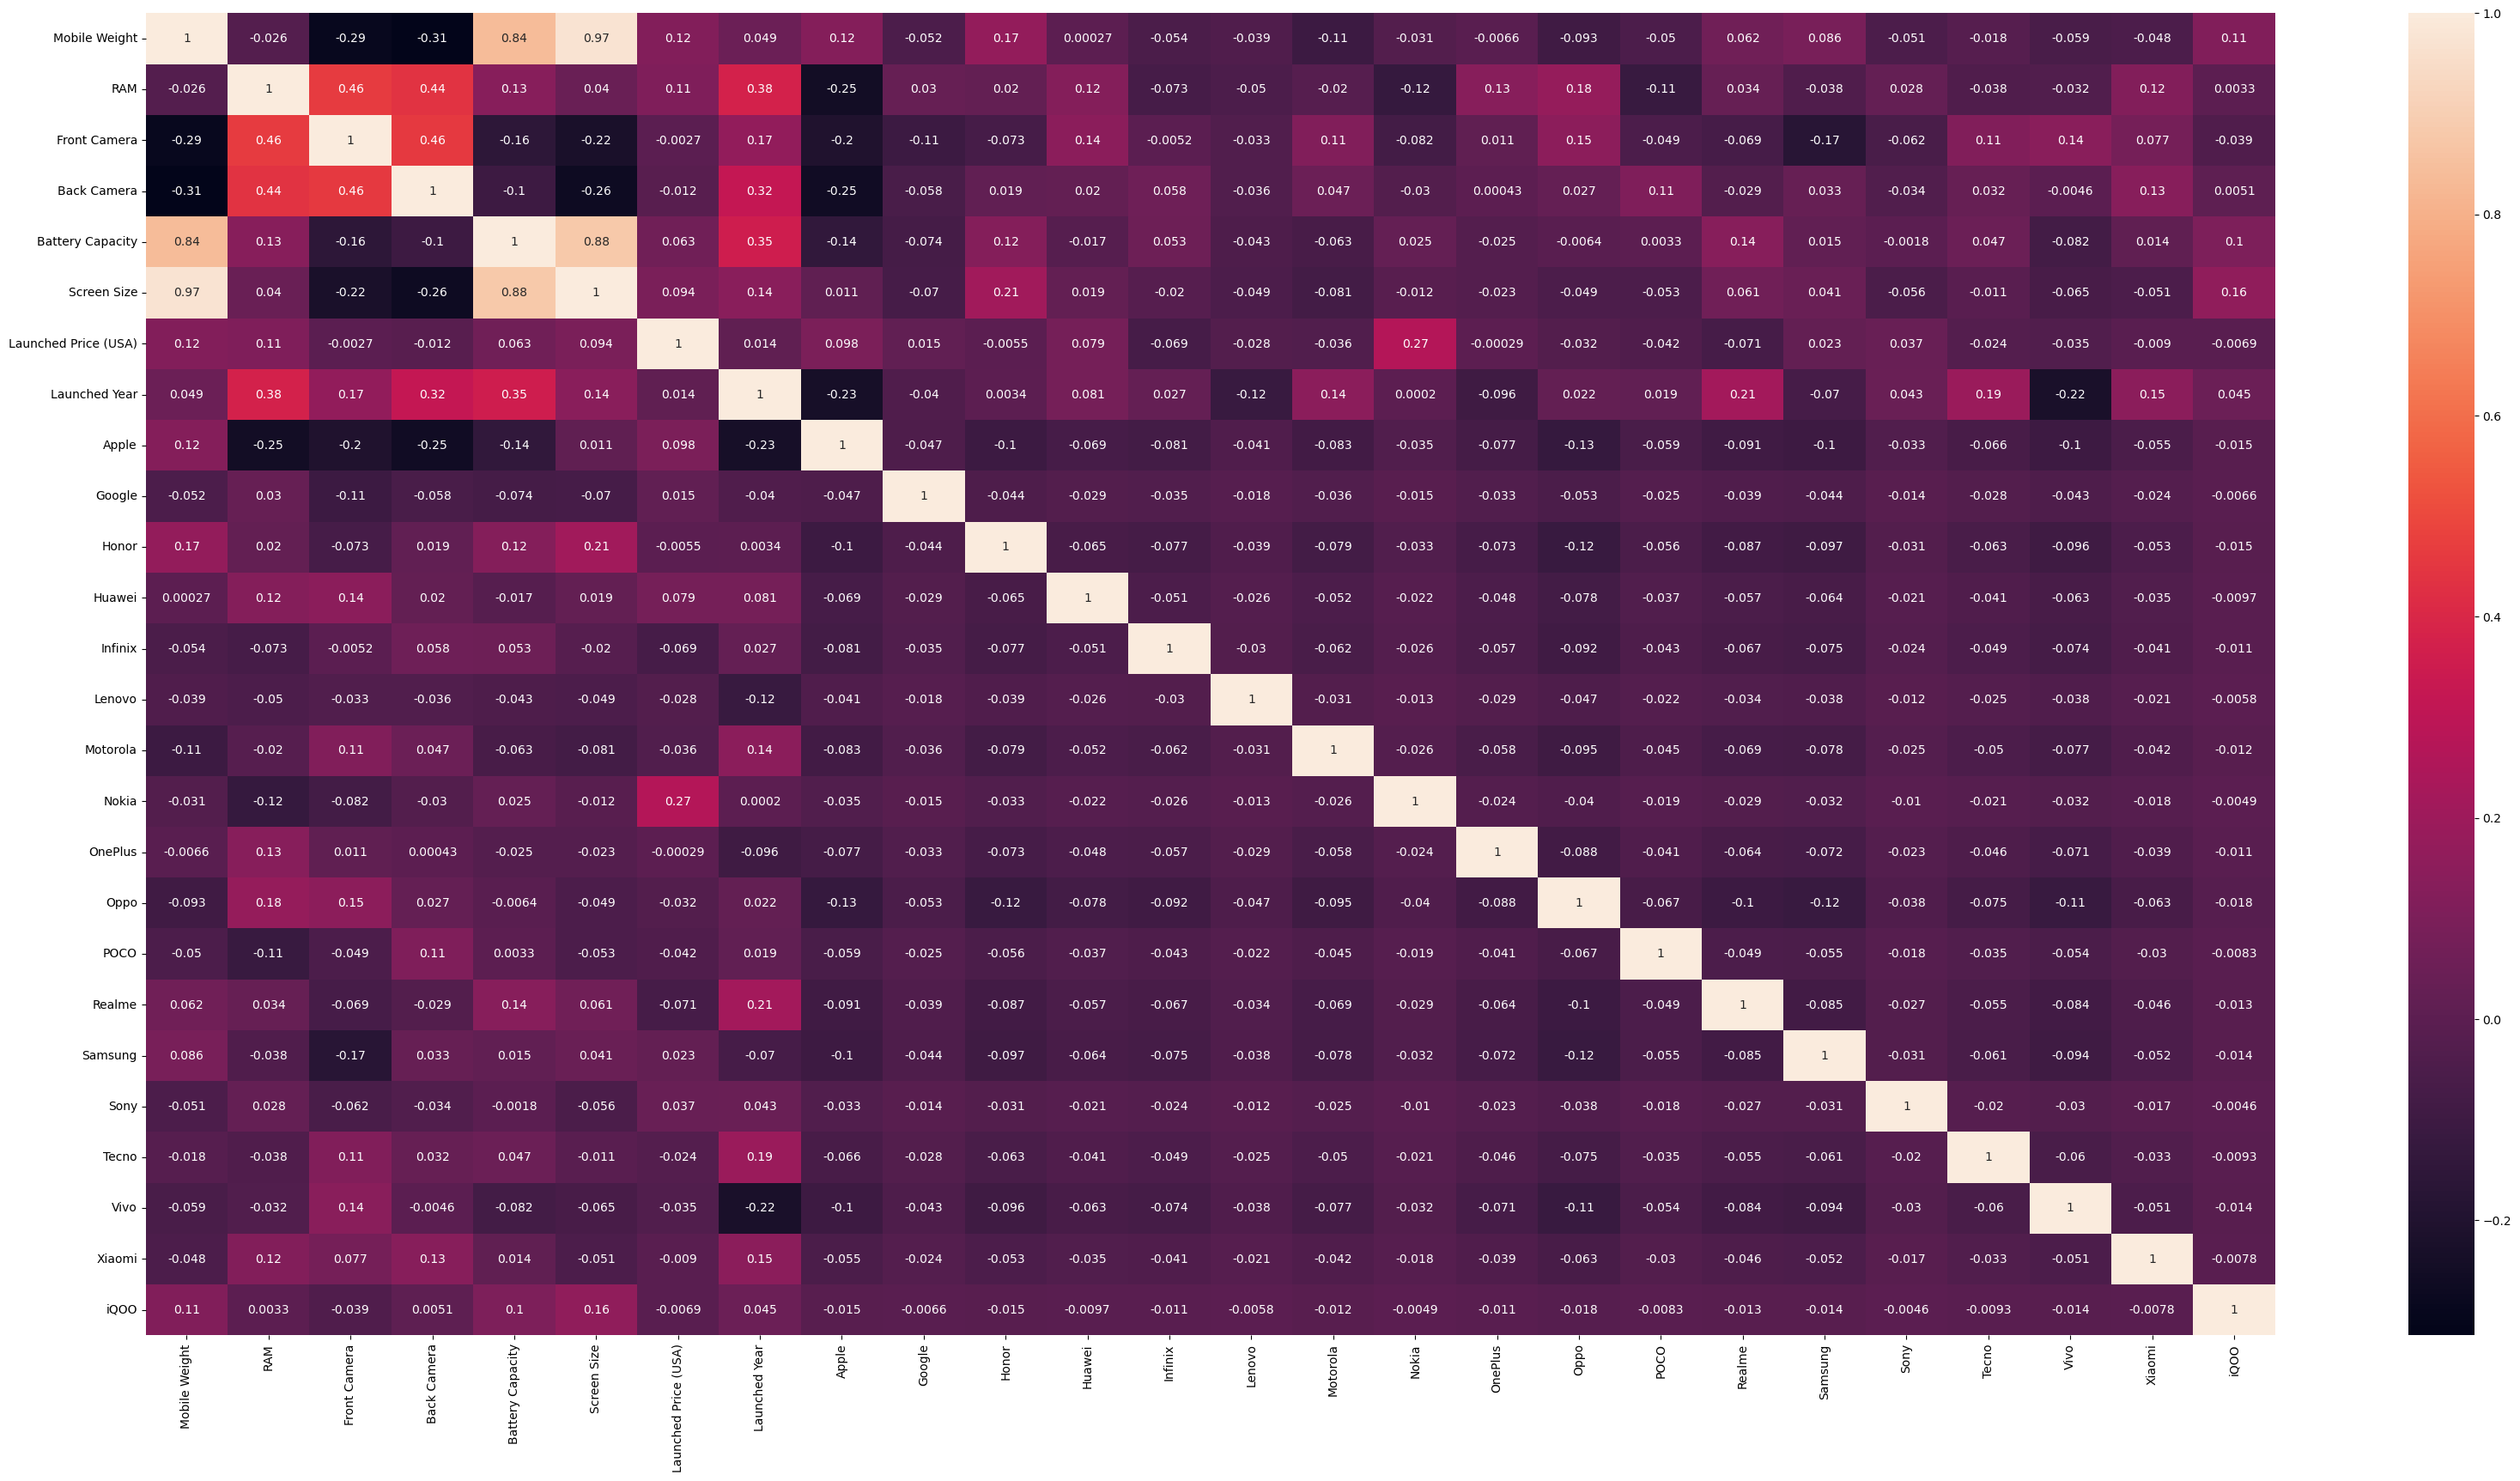

In [264]:
plt.figure(figsize=(40,20))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [265]:
df.drop(columns=['Mobile Weight'],inplace=True)

In [266]:
df.isnull().sum()

RAM                     0
Front Camera            0
Back Camera             0
Battery Capacity        0
Screen Size             0
Launched Price (USA)    0
Launched Year           0
Apple                   0
Google                  0
Honor                   0
Huawei                  0
Infinix                 0
Lenovo                  0
Motorola                0
Nokia                   0
OnePlus                 0
Oppo                    0
POCO                    0
Realme                  0
Samsung                 0
Sony                    0
Tecno                   0
Vivo                    0
Xiaomi                  0
iQOO                    0
dtype: int64

In [267]:
from sklearn.model_selection import train_test_split
X,y=df.drop(columns=['Launched Price (USA)']), df['Launched Price (USA)']
X_train, X_test, Y_train, Y_test = train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.25)

In [268]:
model=LinearRegression()
model.fit(train_X,train_y)
pred_y=model.predict(test_X)

In [202]:
print(f"MAE: {mean_absolute_error(test_y, pred_y)}")
print(f"MAPE: {mean_absolute_percentage_error(test_y, pred_y)}")
print(f"MSE: {mean_squared_error(test_y, pred_y)}")
print(f"RMSE: {root_mean_squared_error(test_y, pred_y)}")
print(f"R2 Score: {r2_score(test_y, pred_y)}")

MAE: 371.950403868988
MAPE: 1.560718335533485
MSE: 1383204.348748509
RMSE: 1176.0970830456595
R2 Score: -7.986386779386299


In [269]:
from xgboost import XGBRegressor

model = XGBRegressor(colsample_bytree=0.3,learning_rate=0.1,max_depth=5,alpha=2,n_estimators=10)
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

In [270]:
!pip install xgboost

In [271]:
print(f"MAE: {mean_absolute_error(test_y, y_pred)}")
print(f"MAPE: {mean_absolute_percentage_error(test_y, y_pred)}")
print(f"MSE: {mean_squared_error(test_y, y_pred)}")
print(f"RMSE: {root_mean_squared_error(test_y, y_pred)}")
print(f"R2 Score: {r2_score(test_y, y_pred)}")

MAE: 376.08223580496656
MAPE: 0.5298168979411888
MSE: 6730506.59163798
RMSE: 2594.3219907401585
R2 Score: -0.00035115665943563634


In [69]:
df.isnull()

,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (USA),Launched Year,Apple,...,Oppo,POCO,Realme,Samsung,Sony,Tecno,Vivo,Xiaomi,iQOO,Batery Capacity
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
918,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
919,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
920,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
921,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
